This file is used to understand the mismatch between:  
1). OSM Road Network    
'/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/OSM_NAI_AOI.gpkg'  

2). Goolge Street View  
'/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/pano_nairobi.csv'  

3). Mapliary   
'/Users/wenlanzhang/Downloads/PhD_UCL/Data/Mapillary/NoInstance/result220924.csv'

4). Base map  
'/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/BaseMap/AoI_Grid50.gpkg'

In [1]:
import geopandas as gpd
from shapely.geometry import Polygon, box

# OSM Road Network 

In [9]:
RoadNet_Path = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/OSM_NAI_AOI.gpkg'
RoadNet = gpd.read_file(RoadNet_Path)
RoadNet

,osm_id,name,ref,type,oneway,bridge,maxspeed,lenght,node_count,geometry
0,4685092,None,B10E,secondary,1,0,NaN,1183.19,21.0,"MULTILINESTRING ((36.91442 -1.34465, 36.91427 ..."
1,4716859,None,None,tertiary,1,0,NaN,17.04,1.0,"MULTILINESTRING ((36.77944 -1.30009, 36.77943 ..."
2,4716860,State House Avenue,D2001,secondary,0,0,NaN,902.79,28.0,"MULTILINESTRING ((36.80434 -1.28648, 36.80449 ..."
3,4716861,Processional Way,None,tertiary,0,0,NaN,138.80,7.0,"MULTILINESTRING ((36.81358 -1.28721, 36.81397 ..."
4,4716862,Kenyatta Avenue,UCB7-Nairobi,secondary,1,0,NaN,166.32,9.0,"MULTILINESTRING ((36.81026 -1.28950, 36.81034 ..."
...,...,...,...,...,...,...,...,...,...,...
65175,1219966300,Ngong Road,D2001,secondary,1,0,NaN,109.91,6.0,"MULTILINESTRING ((36.81257 -1.28979, 36.81240 ..."
65176,1220409349,None,None,residential,0,0,NaN,49.04,1.0,"MULTILINESTRING ((36.90215 -1.27911, 36.90255 ..."
65177,1220409350,None,None,residential,0,0,NaN,75.59,4.0,"MULTILINESTRING ((36.89964 -1.27720, 36.89990 ..."
65178,1220409351,None,None,residential,0,0,NaN,43.14,1.0,"MULTILINESTRING ((36.90245 -1.27870, 36.90280 ..."


<AxesSubplot:>

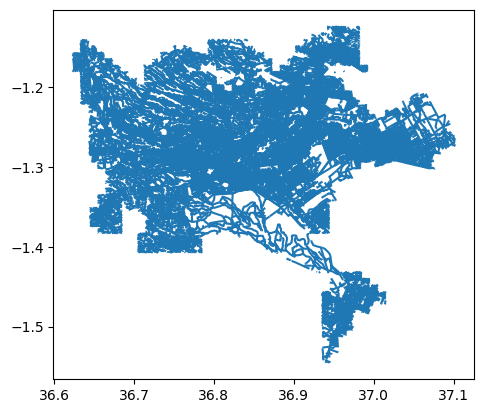

In [10]:
RoadNet.plot()

In [16]:
# Select columns
columns_to_select = ['name', 'type', 'oneway', 'lenght', 'node_count', 'geometry']
new_RoadNet = RoadNet[columns_to_select]
new_RoadNet

,name,type,oneway,lenght,node_count,geometry
0,None,secondary,1,1183.19,21.0,"MULTILINESTRING ((36.91442 -1.34465, 36.91427 ..."
1,None,tertiary,1,17.04,1.0,"MULTILINESTRING ((36.77944 -1.30009, 36.77943 ..."
2,State House Avenue,secondary,0,902.79,28.0,"MULTILINESTRING ((36.80434 -1.28648, 36.80449 ..."
3,Processional Way,tertiary,0,138.80,7.0,"MULTILINESTRING ((36.81358 -1.28721, 36.81397 ..."
4,Kenyatta Avenue,secondary,1,166.32,9.0,"MULTILINESTRING ((36.81026 -1.28950, 36.81034 ..."
...,...,...,...,...,...,...
65175,Ngong Road,secondary,1,109.91,6.0,"MULTILINESTRING ((36.81257 -1.28979, 36.81240 ..."
65176,None,residential,0,49.04,1.0,"MULTILINESTRING ((36.90215 -1.27911, 36.90255 ..."
65177,None,residential,0,75.59,4.0,"MULTILINESTRING ((36.89964 -1.27720, 36.89990 ..."
65178,None,residential,0,43.14,1.0,"MULTILINESTRING ((36.90245 -1.27870, 36.90280 ..."


# Goolge Street View 

In [16]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [21]:
df = pd.read_csv('/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/pano_nairobi.csv')
df = df.iloc[:, 1:]
df

,id,panoid,lat,lon,year,month,marker
0,21,khlXWXsuIX7rodKwi1fDAw,-1.347984,36.904885,2021.0,10.0,True
1,22,E2SmMwWyLCmPNFOl5-XhxA,-1.286567,36.804547,2021.0,9.0,True
2,23,_YVC8LQsymlhhIFp0go_7g,-1.286704,36.804986,2021.0,9.0,True
3,24,BOFAYq7l0PF7Lg2_Kn258w,-1.286835,36.805475,2021.0,9.0,True
4,25,K3_Pj41onnAOLziZiZeGIw,-1.286968,36.805993,2021.0,9.0,True
...,...,...,...,...,...,...,...
126409,213600,f1wVXeQLsTbfDdX1IgZvSg,-1.318228,36.854663,2018.0,1.0,True
126410,213603,U3VouvYaIateSuoSEz6I9Q,-1.318704,36.853164,2021.0,7.0,True
126411,213604,xxfDzMmO__DBRl9my1XA1g,-1.289720,36.812128,2018.0,2.0,True
126412,213605,joG2cf6Yga4GW1DA2UdVcw,-1.289322,36.811855,2021.0,7.0,True


In [23]:
# Create a GeoDataFrame with Point geometries
geometry = [Point(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]
gsv = gpd.GeoDataFrame(df, geometry=geometry)
gsv.drop(columns=['id', 'lat', 'lon', 'marker'], inplace=True)
gsv

,panoid,year,month,geometry
0,khlXWXsuIX7rodKwi1fDAw,2021.0,10.0,POINT (36.90489 -1.34798)
1,E2SmMwWyLCmPNFOl5-XhxA,2021.0,9.0,POINT (36.80455 -1.28657)
2,_YVC8LQsymlhhIFp0go_7g,2021.0,9.0,POINT (36.80499 -1.28670)
3,BOFAYq7l0PF7Lg2_Kn258w,2021.0,9.0,POINT (36.80547 -1.28684)
4,K3_Pj41onnAOLziZiZeGIw,2021.0,9.0,POINT (36.80599 -1.28697)
...,...,...,...,...
126409,f1wVXeQLsTbfDdX1IgZvSg,2018.0,1.0,POINT (36.85466 -1.31823)
126410,U3VouvYaIateSuoSEz6I9Q,2021.0,7.0,POINT (36.85316 -1.31870)
126411,xxfDzMmO__DBRl9my1XA1g,2018.0,2.0,POINT (36.81213 -1.28972)
126412,joG2cf6Yga4GW1DA2UdVcw,2021.0,7.0,POINT (36.81186 -1.28932)


# Base Map
## Create a grid from the boundary
Done in QGIS: Create the Grid (Tool: Create Grid) - Reproject to 4326 - Clip the Grid to the Boundary (Tool: Clip):   
'/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/BaseMap/AoI_Grid50.gpkg'

In [8]:
BasePath = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/BaseMap/AoI_Grid50.gpkg'
BaseGrid = gpd.read_file(BasePath)
BaseGrid

,id,left,top,right,bottom,geometry
0,73,4.076857e+06,-128754.852908,4.076907e+06,-128804.852908,"MULTIPOLYGON (((36.62303 -1.15657, 36.62303 -1..."
1,74,4.076857e+06,-128804.852908,4.076907e+06,-128854.852908,"MULTIPOLYGON (((36.62304 -1.15700, 36.62348 -1..."
2,75,4.076857e+06,-128854.852908,4.076907e+06,-128904.852908,"MULTIPOLYGON (((36.62304 -1.15744, 36.62348 -1..."
3,76,4.076857e+06,-128904.852908,4.076907e+06,-128954.852908,"MULTIPOLYGON (((36.62304 -1.15789, 36.62348 -1..."
4,77,4.076857e+06,-128954.852908,4.076907e+06,-129004.852908,"MULTIPOLYGON (((36.62305 -1.15834, 36.62348 -1..."
...,...,...,...,...,...,...
460120,1003841,4.130407e+06,-140804.852908,4.130457e+06,-140854.852908,"MULTIPOLYGON (((37.10420 -1.26507, 37.10420 -1..."
460121,1003842,4.130407e+06,-140854.852908,4.130457e+06,-140904.852908,"MULTIPOLYGON (((37.10437 -1.26567, 37.10408 -1..."
460122,1003843,4.130407e+06,-140904.852908,4.130457e+06,-140954.852908,"MULTIPOLYGON (((37.10441 -1.26581, 37.10441 -1..."
460123,1003844,4.130407e+06,-140954.852908,4.130457e+06,-141004.852908,"MULTIPOLYGON (((37.10423 -1.26656, 37.10408 -1..."


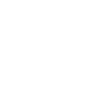

In [11]:
cell_value = BaseGrid.loc[2, 'geometry']
cell_value

In [12]:
BaseGrid['geometry'] = BaseGrid['geometry'].apply(lambda geom: geom[0] if geom.type == 'MultiPolygon' else geom)
BaseGrid

/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_48622/604755955.py:1: ShapelyDeprecationWarning: __getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  BaseGrid['geometry'] = BaseGrid['geometry'].apply(lambda geom: geom[0] if geom.type == 'MultiPolygon' else geom)


,id,left,top,right,bottom,geometry
0,73,4.076857e+06,-128754.852908,4.076907e+06,-128804.852908,"POLYGON ((36.62303 -1.15657, 36.62303 -1.15657..."
1,74,4.076857e+06,-128804.852908,4.076907e+06,-128854.852908,"POLYGON ((36.62304 -1.15700, 36.62348 -1.15700..."
2,75,4.076857e+06,-128854.852908,4.076907e+06,-128904.852908,"POLYGON ((36.62304 -1.15744, 36.62348 -1.15744..."
3,76,4.076857e+06,-128904.852908,4.076907e+06,-128954.852908,"POLYGON ((36.62304 -1.15789, 36.62348 -1.15789..."
4,77,4.076857e+06,-128954.852908,4.076907e+06,-129004.852908,"POLYGON ((36.62305 -1.15834, 36.62348 -1.15834..."
...,...,...,...,...,...,...
460120,1003841,4.130407e+06,-140804.852908,4.130457e+06,-140854.852908,"POLYGON ((37.10420 -1.26507, 37.10420 -1.26507..."
460121,1003842,4.130407e+06,-140854.852908,4.130457e+06,-140904.852908,"POLYGON ((37.10437 -1.26567, 37.10408 -1.26567..."
460122,1003843,4.130407e+06,-140904.852908,4.130457e+06,-140954.852908,"POLYGON ((37.10441 -1.26581, 37.10441 -1.26581..."
460123,1003844,4.130407e+06,-140954.852908,4.130457e+06,-141004.852908,"POLYGON ((37.10423 -1.26656, 37.10408 -1.26656..."


<AxesSubplot:>

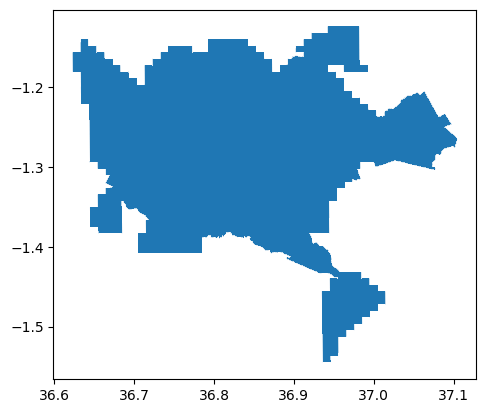

In [13]:
BaseGrid.plot()

# Macth OSM, GSV, MSV to Base 

## Match OSM to Base